<a href="https://colab.research.google.com/github/raihan-uddinahmed/bioinformatics-basics/blob/main/notebooks/PASTA_multiple_sequence_alingments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section A: Study of the Paper PASTA

## What problem in large-scale MSA does PASTA aim to solve?

Popular multiple sequence alignment based tree estimation suffers in terms of scalability due to the progressive aligment based techniques. Traditional alignment methods such as MUSCLE or clusterW require calculating the distance matrix for every pair of the sequence and introduce an exponential complexity when the number of sqeunces are higher (1000 or more).

For $N$ sequences in comparison, there are $\frac{N(N-1)}{2}$ pair-wise comparisons (for 1000 sequences it's 499500).

Additionally, in bioinformatics, any error in the initial guide tree estimation will result into a circular spiral of errors in the subsequent trees. For accurate estimation of the phylogenic trees, it is therefore mandatory to remove any biases in the initial steps of tree estimation by using a codependent method of sequence and tree alignment. FUrthermore, for sequences with higly evolving (multiple insetion or deletion), the progressive alignment methods, suffer from the  placements. For highly divergent sequences, it may result in a completely misleading tree estimation.   

## Explain the divide-and-conquer strategy used in PASTA.

PASTA (practical alignment using SATé and TrAnsitivity) uses an iterative strategy to implement the divide and conquer methods for sequence alignment as well tree estimation. There are six steps as demonstrated in the original paper.

*   **Step-1:** Decomposition --The first guide tree initialy estimates several subsets of the sequences.
*   **Step-2:** Spanning Tree -- The subsets are used as nodes to span the inintial tree by connecting them as branches.
*   **Step-3:** MSA Alignment: independent MSA of the subsets are calculated.
*   **Step-4:** Pairwise Merge --pairwise MSA of the subsets that are closer in the traditional alignment calulation methods are merged.
*   **Step-5:** Transitivity -- MSA subsets that are overlapped are combined using transitivity to create an updated tree from the initial guide
*   **Step-6:** Tree Estimation -- an additional iteration over the tree to further refine using the updated subsets based on the MSA where highly aligned subsets are masked to impover computational efficiency.




## Why does PASTA iterate between alignment and tree estimation?

PASTA alternates between alignment and tree estimation due to its "co-estimation" technique, wherein the precision of each component is contingent upon the other. The procedure initiates with a guide tree to partition the extensive sequence set into smaller, manageable subsets, which are subsequently aligned and amalgamated using a transitivity-based method to create a comprehensive multiple sequence alignment (MSA). Subsequently, by estimating a new maximum likelihood tree from the resultant MSA, PASTA can utilize that enhanced tree to refine the decomposition in the subsequent iteration, thereby rectifying biases or errors created by the initial starting tree. This repeated feedback loop enables the method to attain excellent accuracy and scalability, even with ultra-large datasets of up to 200,000 sequences, substantially surpassing single-pass methods that may be constrained by the quality of a static starting tree.

## How does PASTA differ from classical progressive alignment

Classical progressive aligments are often-times dependent on a single-pass hierarchical approach. When the sequence counts reach number greater than a thousand or more, such progressive aligners suffer from the computational overhead. This introduces a performance wall. PASTA circumvents such difficulties by using the divide and conquer approach through an iterative centroid-decomposition of the initial guide tree and uses the maximum likelihood estimation of subsequent trees combining the MSA of disjoint subsets of sequences.

## What are the computational bottlenecks in PASTA

The specific computational bottlenecks in PASTA are listed below.

*   **Pariwise Alignment of Subsets** - Aligning the type 1 subalignments using OPAL to produce type 2 subalignments involves aligning alignments of up to $2k$ sequences. In previous iterations of related algorithms like SATé-II, running OPAL on large datasets was so computationally costly that researchers had to switch to MUSCLE for datasets exceeding 5,000 sequences.
*   **Transitivity Merger** - The transitivity merge (Step 5) is designed to be efficient, but its worst-case running time can reach $O(qm^2+Lm)$ depending on the edge contraction order. PASTA optimizes this to $O(qm \log m+ Lm)$ by merging subalignments in the reverse order of centroid edge deletions.

# Section B: Pairwise Sequence Alignment

## Data Imports

In [ ]:
!pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.9 MB/s eta 0:00:00


In [ ]:
from Bio import ExPASy
from Bio import SeqIO


# Function to fetch sequence from Uniprot
def fetch_uniprot_sequence(uniprot_id):
    try:
        with ExPASy.get_sprot_raw(uniprot_id) as handle:
            seq_record = SeqIO.read(handle, "swiss")
            return str(seq_record.seq)
    except Exception as e:
        return f"Error fetching {uniprot_id}: {e}"

In [ ]:
import pandas as pd

# uniprot_data = {
#     "Human_HBA1": "P69905",
#     "Chimpanzee_HBA": "P69907",
#     "Gorilla_HBA": "A0A6J4V2Z4",
#     "Orangutan_HBA": "A0A8J8XLS1",
#     "Rhesus_Macaque_HBA": "P63108",
#     "Dog_HBA": "P01934",
#     "Cow_HBA": "P01937",
#     "Sheep_HBA": "P09971",
#     "Pig_HBA": "P80015",
#     "Horse_HBA": "P01930",
#     "Mouse_HBA-a1": "P01912",
#     "Rat_HBA-a1": "P00600",
#     "Rabbit_HBA": "P00652",
#     "Chicken_HBA-D": "P09947",
#     "Frog_HBA": "P02051",
#     "Zebrafish_HBA": "Q9DFX4",
#     "Shark_HBA": "P02021" # Correct uniprot reference for Shark_HBA
# }

uniprot_data = {
    "Human_HBA1": "P69905",
    "Chimpanzee_HBA": "P69907",
    "Gorilla_HBA": "P01923",
    "Orangutan_HBA": "P06635",
    "Rhesus_Macaque_HBA": "P63108",
    "Dog_HBA": "P01942",
    "Cow_HBA": "P01966",
    "Sheep_HBA": "P01968",
    "Pig_HBA": "P01965",
    "Horse_HBA": "P01958",
    "Mouse_HBA-a1": "P01942",
    "Rat_HBA-a1": "P01946",
    "Rabbit_HBA": "P01948",
    "Chicken_HBA-D": "P02001",
    "Frog_HBA": "P02051",
    "Zebrafish_HBA": "Q9DFX4",
    "Shark_HBA": "P02021"
}

protien_data = []

for name, ref in uniprot_data.items():
    sequence = fetch_uniprot_sequence(ref)
    protien_data.append({"Protien_Name": name, "UniProt_ID": ref, "Sequence": sequence})

# Dataframe to work with

protien_df = pd.DataFrame(protien_data)
protien_df.head(5)



,Protien_Name,UniProt_ID,Sequence
0,Human_HBA1,P69905,MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
1,Chimpanzee_HBA,P69907,MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
2,Gorilla_HBA,P01923,VLSPADKTNVKAAWGKVGAHAGDYGAEALERMFLSFPTTKTYFPHF...
3,Orangutan_HBA,P06635,MVLSPADKTNVKTAWGKVGAHAGDYGAEALERMFLSFPTTKTYFPH...
4,Rhesus_Macaque_HBA,P63108,MVLSPADKSNVKAAWGKVGGHAGEYGAEALERMFLSFPTTKTYFPH...


In [ ]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

# BioPython Sequential Record Object
records = []

for index, row in protien_df.iterrows():
    seq_record = SeqRecord(
        Seq(row['Sequence']),
        id=row['Protien_Name'],
        description=row['UniProt_ID']
    )
    records.append(seq_record)

# Creating a FASTA file for the protein sequences
filename = "hba_sequences.fasta"
with open(filename, "w") as output_handle:
    SeqIO.write(records, output_handle, "fasta")


## Pairwise Alignments

### Human_HBA1 and Chimpanzee_HBA

In [ ]:
# Extracting from our previously created DataFrame
seq_human = protien_df[protien_df['Protien_Name'] == 'Human_HBA1']['Sequence'].values[0]
seq_chimp = protien_df[protien_df['Protien_Name'] == 'Chimpanzee_HBA']['Sequence'].values[0]

# seq_chimp = "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR"

print(f"Human Sequence Length: {len(seq_human)}")
print(f"Chimp Sequence Length: {len(seq_chimp)}")

Human Sequence Length: 142
Chimp Sequence Length: 142


In [ ]:
from Bio import Align
from Bio.Align import substitution_matrices


global_aligner = Align.PairwiseAligner()
global_aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")

# GAP parameters
global_aligner.open_gap_score = -5
global_aligner.extend_gap_score = -1

# First the global alignment (Needleman-Wunsch)
global_aligner.mode = "global"
global_alignments = global_aligner.align(seq_human, seq_chimp)

best_global = global_alignments[0]
print(f'Global Alignment Score: {best_global.score}')
print(best_global)


Global Alignment Score: 733.0
target            0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG

target           60 KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            60 KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP

target          120 AVHASLDKFLASVSTVLTSKYR 142
                120 |||||||||||||||||||||| 142
query           120 AVHASLDKFLASVSTVLTSKYR 142



In [ ]:
# Local Alignment Scores (Smith-Waterman)
local_aligner = Align.PairwiseAligner()

local_aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")

# GAP parameters
local_aligner.open_gap_score = -5
local_aligner.extend_gap_score = -1

local_aligner.mode = "local"
local_alignments = local_aligner.align(seq_human, seq_chimp)

best_local = local_alignments[0]
print(f'Local Alignment Score: {best_local.score}')
print(best_local)

Local Alignment Score: 733.0
target            0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG

target           60 KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            60 KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP

target          120 AVHASLDKFLASVSTVLTSKYR 142
                120 |||||||||||||||||||||| 142
query           120 AVHASLDKFLASVSTVLTSKYR 142



In [ ]:
print(f'Global Alignment Score: {best_global.score}')
print(f'Local Alignment Score: {best_local.score}')

print(f'Global Alignment = {global_alignments[0]}')
print(f'Local Alignment = {local_alignments[0]}')

Global Alignment Score: 733.0
Local Alignment Score: 733.0
Global Alignment = target            0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG

target           60 KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            60 KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP

target          120 AVHASLDKFLASVSTVLTSKYR 142
                120 |||||||||||||||||||||| 142
query           120 AVHASLDKFLASVSTVLTSKYR 142

Local Alignment = target            0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG
                  0 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG

target           60 KKVADALTNA

Since the $2$ sequences are exactly equivalent, there local and global aligments are equal - demonstrating highest possibile genetic similarity for the HBA protien

# Section C

In [ ]:
import numpy as np
import pandas as pd
from Bio import Align
from Bio.Align import substitution_matrices
from Bio.Phylo.TreeConstruction import DistanceMatrix

# Alinger
aligner = Align.PairwiseAligner()
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -5
aligner.extend_gap_score = -1
aligner.mode = 'global'

# Protien names
names = protien_df['Protien_Name'].to_list()
dis_mat = np.zeros((len(names), len(names)))

for i in range(len(names)):
  for j in range(len(names)):
      dis_mat[i, j] = aligner.score(protien_df['Sequence'][i], protien_df['Sequence'][j])

distance = []
for i in range(len(names)):
  row = []
  for j in range(i+1):
      d = dis_mat[i,i] - dis_mat[i, j]
      row.append(max(0,d))
  distance.append(row)

dm = DistanceMatrix(names, distance)



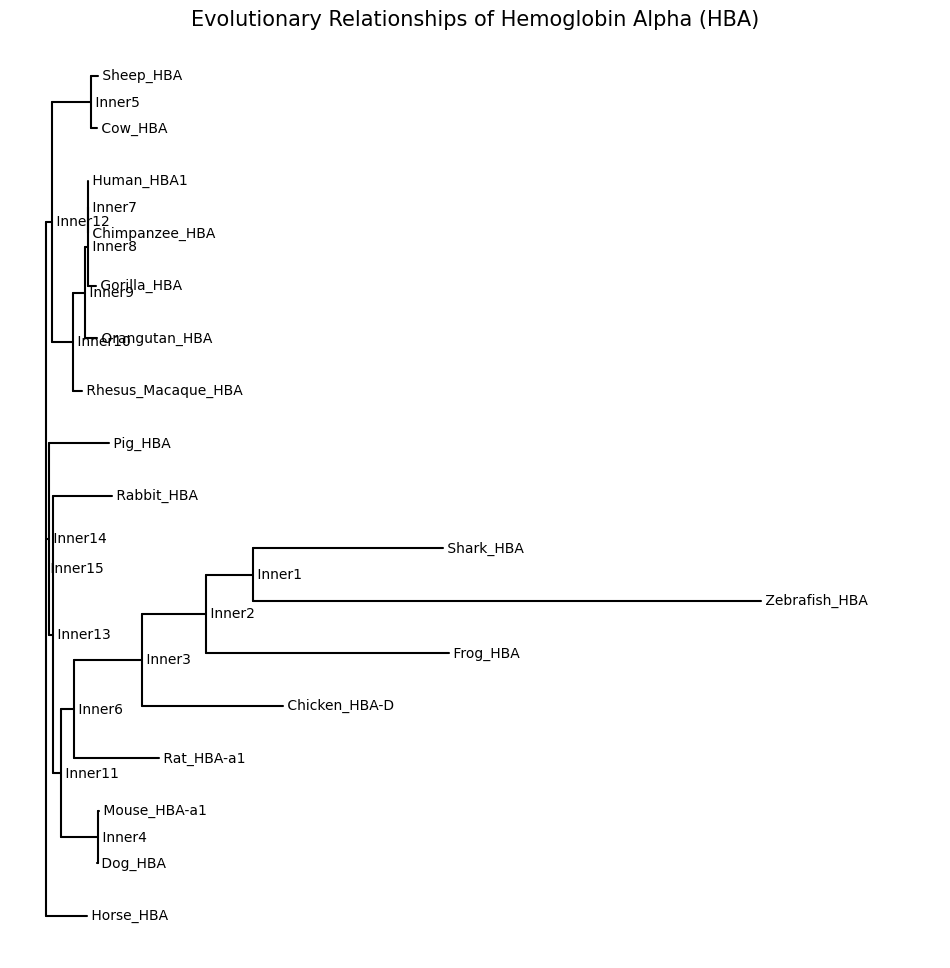

In [ ]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
from Bio import Phylo
import matplotlib.pyplot as plt


constructor = DistanceTreeConstructor()


nj_tree = constructor.nj(dm)

# fig = plt.figure(figsize=(10, 8), dpi=100)
# axes = fig.add_subplot(1, 1, 1)
# Phylo.draw(nj_tree, axes=axes)
# plt.show()


fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1)

# Constructing the Phylogenic tree
Phylo.draw(nj_tree,
           axes=ax,
           branch_labels=lambda x: None,
           do_show=False)

ax.set_title("Evolutionary Relationships of Hemoglobin Alpha (HBA)", fontsize=15)
ax.axis('off') # Remove the grid/axes for a 'stunning' feel
plt.show()

In [ ]:
!pip install toytree
!pip install toyplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.6/467.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.2/279.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.1 MB/s eta 0:00:00


In [ ]:
import toytree
import toyplot
from Bio import Phylo
from io import StringIO


netwick_io = StringIO()
Phylo.write(nj_tree, netwick_io, "newick")
newick_string = netwick_io.getvalue()


tree = toytree.tree(newick_string)

canvas, axes, mark = tree.draw(layout='d')

axes.label.text = "Phylogenetic Analysis of HBA Sequences (Section C)"
canvas.style = {"background-color": "white"}

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="381.52000000000004px" height="472.104px" viewBox="0 0 381.52000000000004 472.104" preserveAspectRatio="xMidYMid meet" style="background-color:white;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t2df6f459ec1446539d732a07e8525eca"> Sheep_HBA Cow_HBA Human_HBA1 Chimpanzee_HBA Gorilla_HBA Orangutan_HBA Rhesus_Macaque_HBA Pig_HBA Rabbit_HBA Shark_HBA Zebrafish_HBA Frog_HBA Chicken_HBA-D Rat_HBA-a1 Mouse_HBA-a1 Dog_HBA Horse_HBA Phylogenetic Analysis of HBA Sequences (Section C)

From the phylogenic tree - we can infer that most of the primates are clustered together with human, chimpanzee and gorilla as perfect SA and they are related to the other primate sequence.

As per the tree, fish and other mammals are also quite distant from each other.

Interesting observation for the Chiken_HBA-D is the phylogenic tree branch is in between the acuatic and terrestrial animals, designating evolutionary transitions.

# Section D

## MUSCLE

In [ ]:
!apt-get install -y muscle

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  muscle
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 244 kB of archives.
After this operation, 709 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 muscle amd64 1:3.8.1551-2build1 [244 kB]
Fetched 244 kB in 2s (163 kB/s)
Selecting previously unselected package muscle.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../muscle_1%3a3.8.1551-2build1_amd64.deb ...
Unpacking muscle (1:3.8.1551-2build1) ...
Setting up muscle (1:3.8.1551-2build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!muscle -in hba_sequences.fasta -out hba_aligned.fasta


MUSCLE v3.8.1551 by Robert C. Edgar

http://www.drive5.com/muscle
This software is donated to the public domain.
Please cite: Edgar, R.C. Nucleic Acids Res 32(5), 1792-97.

hba_sequences 17 seqs, lengths min 141, max 161, avg 143
00:00:00     16 MB(4%)  Iter   1  100.00%  K-mer dist pass 1
00:00:00     16 MB(4%)  Iter   1  100.00%  K-mer dist pass 2
00:00:00     19 MB(5%)  Iter   1  100.00%  Align node
00:00:00     19 MB(5%)  Iter   1  100.00%  Root alignment
00:00:00     19 MB(5%)  Iter   2  100.00%  Refine tree
00:00:00     19 MB(5%)  Iter   2  100.00%  Root alignment
00:00:00     19 MB(5%)  Iter   2  100.00%  Root alignment
00:00:00     19 MB(5%)  Iter   3  100.00%  Refine biparts
00:00:00     19 MB(5%)  Iter   4  100.00%  Refine biparts
00:00:00     19 MB(5%)  Iter   5  100.00%  Refine biparts
00:00:00     19 MB(5%)  Iter   6  100.00%  Refine biparts
00:00:00     19 MB(5%)  Iter   7  100.00%  Refine biparts
00:00:00     19 MB(5%)  Iter   8  100.00%  Refine biparts
00:00:00     19 

In [ ]:
import os
from Bio import AlignIO, SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

alignment = AlignIO.read("hba_aligned.fasta", "fasta")
print("Alignment length:", alignment.get_alignment_length())

Alignment length: 174


In [ ]:
import toytree
from io import StringIO
from Bio import Phylo

calculator = DistanceCalculator('identity')
dm_msa = calculator.get_distance(alignment)
constructor = DistanceTreeConstructor()
msa_tree = constructor.nj(dm_msa)

netwick_io = StringIO()
Phylo.write(msa_tree, netwick_io, "newick")
msa_newick = netwick_io.getvalue()


tree_msa = toytree.tree(msa_newick)
canvas, axes, mark = tree_msa.draw(
    layout='d',
    tip_labels_align=True,
    node_sizes=6,
    node_colors="black",
    width=800,
    height=500,
    edge_style={
        "stroke": "#2c3e50",
        "stroke-width": 2
    }
)

axes.label.text = "Section D: MUSCLE MSA-based Phylogeny"
canvas.style = {"background-color": "white"}

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="800.0px" height="500.0px" viewBox="0 0 800.0 500.0" preserveAspectRatio="xMidYMid meet" style="background-color:white;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t1e1c7ac9ec674339aa6114455cfd8665"> Chimpanzee_HBA Human_HBA1 Gorilla_HBA Orangutan_HBA Rhesus_Macaque_HBA Shark_HBA Zebrafish_HBA Frog_HBA Chicken_HBA-D Mouse_HBA-a1 Dog_HBA Rat_HBA-a1 Rabbit_HBA Sheep_HBA Cow_HBA Pig_HBA Horse_HBA Section D: MUSCLE MSA-based Phylogeny (Bonus)

In [ ]:
import toytree
import toyplot
from io import StringIO
from Bio import Phylo


netwick_c = StringIO()
Phylo.write(nj_tree, netwick_c, "newick")
tree_c = toytree.tree(netwick_c.getvalue())


netwick_d = StringIO()
Phylo.write(msa_tree, netwick_d, "newick")
tree_d = toytree.tree(netwick_d.getvalue())


canvas = toyplot.Canvas(width=1000, height=500)

# Left Plot: Section C
axes_c = canvas.cartesian(grid=(1, 2, 0))
tree_c.draw(
    layout='d',
    axes=axes_c,
    tip_labels_align=True,
    edge_style={"stroke": "#e67e22", "stroke-width": 2},
    node_sizes=5
)
axes_c.label.text = "Section C: Pairwise Score Tree"

# Right Plot: Section D
axes_d = canvas.cartesian(grid=(1, 2, 1))
tree_d.draw(
    layout='d',
    axes=axes_d,
    tip_labels_align=True,
    edge_style={"stroke": "#2980b9", "stroke-width": 2},
    node_sizes=5
)
axes_d.label.text = "Section D: MUSCLE MSA Tree"

canvas.style = {"background-color": "white"}

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="1000.0px" height="500.0px" viewBox="0 0 1000.0 500.0" preserveAspectRatio="xMidYMid meet" style="background-color:white;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t937e5b9c75744ea4becabae3ff7f5228"> Sheep_HBA Cow_HBA Human_HBA1 Chimpanzee_HBA Gorilla_HBA Orangutan_HBA Rhesus_Macaque_HBA Pig_HBA Rabbit_HBA Shark_HBA Zebrafish_HBA Frog_HBA Chicken_HBA-D Rat_HBA-a1 Mouse_HBA-a1 Dog_HBA Horse_HBA 0 5 10 15 -400 0 400 800 Section C: Pairwise Score Tree Chimpanzee_HBA Human_HBA1 Gorilla_HBA Orangutan_HBA Rhesus_Macaque_HBA Shark_HBA Zebrafish_HBA Frog_HBA Chicken_HBA-D Mouse_HBA-a1 Dog_HBA Rat_HBA-a1 Rabbit_HBA Sheep_HBA Cow_HBA Pig_HBA Horse_HBA 0 5 10 15 -0.5 0.0 0.5 1.0 Section D: MUSCLE MSA Tree

Both trees are seemingly the same however, the observed evolutionary changes in MUSCLE tree is more profound compared to the Pair Wise Alignment score tree.